# Aggregate Supply & Consumer Sentiment Dashboard

Merge Philadelphia Fed SPF 1-year-ahead CPI forecasts with FRED consumer series and the NY Fed GSCPI.

In [1]:
from dotenv import load_dotenv

from src.data_loader import build_master_frame, fetch_monthly_for_plots
from src.plots import plot_expectations_gap

load_dotenv()

df = build_master_frame(start="2018-01-01")
monthly = fetch_monthly_for_plots(start="2018-01-01")

In [2]:
df.head()

,spf_cpi_1yr,gscpi,mich,umcsent
quarter_end,,,,
2018-03-31 00:00:00.000000,2.211700,0.356667,2.733333,98.933333
2018-03-31 23:59:59.999999,2.211700,0.357582,2.734432,98.926740
2018-06-30 00:00:00.000000,2.259173,0.440000,2.833333,98.333333
2018-06-30 23:59:59.999999,2.259700,0.440399,2.833696,98.330435
2018-09-30 00:00:00.000000,2.258909,0.476667,2.866667,98.066667


In [3]:
df.info()
print("Missing values per column:")
print(df.isna().sum())

<class 'pandas.DataFrame'>
DatetimeIndex: 68 entries, 2018-03-31 00:00:00 to 2026-06-30 23:59:59.999999
Data columns (total 4 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   spf_cpi_1yr  68 non-null     float64
 1   gscpi        68 non-null     float64
 2   mich         68 non-null     float64
 3   umcsent      68 non-null     float64
dtypes: float64(4)
memory usage: 2.7 KB
Missing values per column:
spf_cpi_1yr    0
gscpi          0
mich           0
umcsent        0
dtype: int64


In [4]:
corr = df[["gscpi", "mich", "umcsent", "spf_cpi_1yr"]].corr()
corr

,gscpi,mich,umcsent,spf_cpi_1yr
gscpi,1.000000,0.363720,-0.101038,0.086558
mich,0.363720,1.000000,-0.770458,0.798622
umcsent,-0.101038,-0.770458,1.000000,-0.680130
spf_cpi_1yr,0.086558,0.798622,-0.680130,1.000000


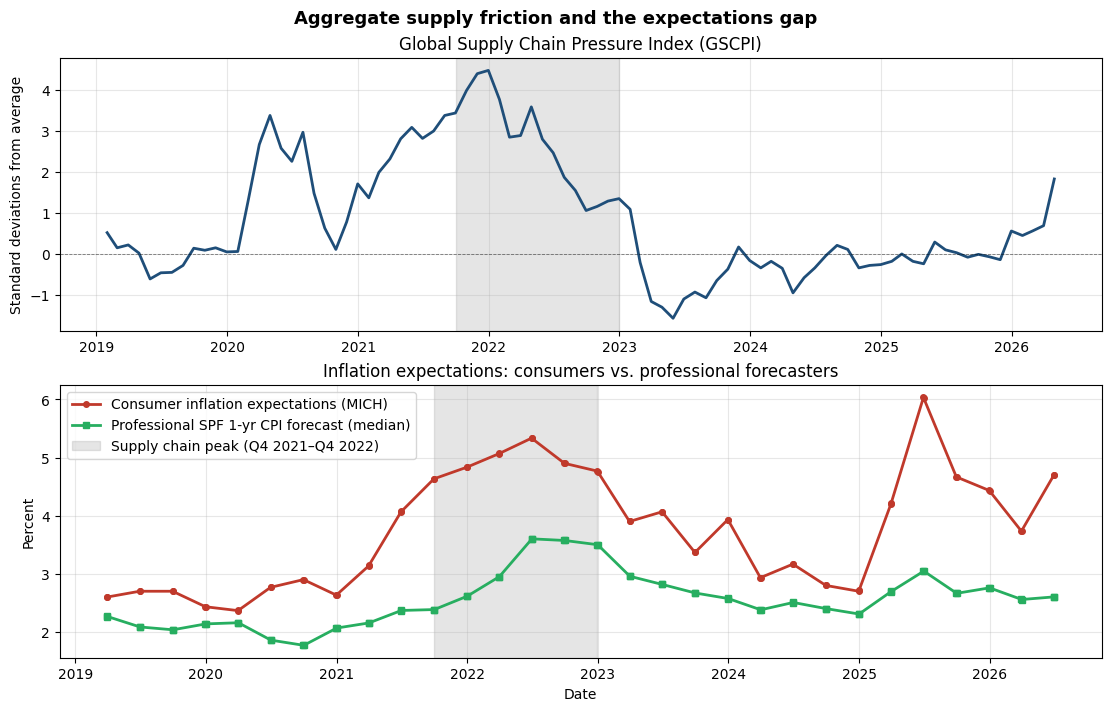

In [5]:
import matplotlib.pyplot as plt
from pathlib import Path

fig = plot_expectations_gap(df, monthly["gscpi"], plot_start="2019-01-01", plot_end="2026-12-31")
Path("figures").mkdir(exist_ok=True)
fig.savefig("figures/friction_sentiment.png", dpi=150, bbox_inches="tight")
plt.show()